In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [34]:
df = pd.read_csv(r"D:\Uniliver Limited\mobile_phone_pricing\Mobile Phone Pricing\dataset.csv")
print(df.shape)
df.head()


(2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [35]:
# Feature ?Target Split
X = df.drop("price_range", axis=1)
y = df["price_range"]


In [36]:
# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    
)


In [37]:
# Model 1 – Logistic Regression (Baseline)
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



In [38]:
# Model 2 – Random Forest (Non-Linear)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.80      0.82      0.81       100
           2       0.82      0.81      0.81       100
           3       0.96      0.94      0.95       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [39]:
# Feature Importance 
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


ram              0.483102
battery_power    0.074234
px_width         0.057801
px_height        0.055615
mobile_wt        0.038501
int_memory       0.035762
talk_time        0.029916
pc               0.029594
sc_w             0.027995
clock_speed      0.027190
dtype: float64

In [40]:
# Model 3 – XGBoost 
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       100
           1       0.92      0.91      0.91       100
           2       0.87      0.89      0.88       100
           3       0.95      0.92      0.93       100

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



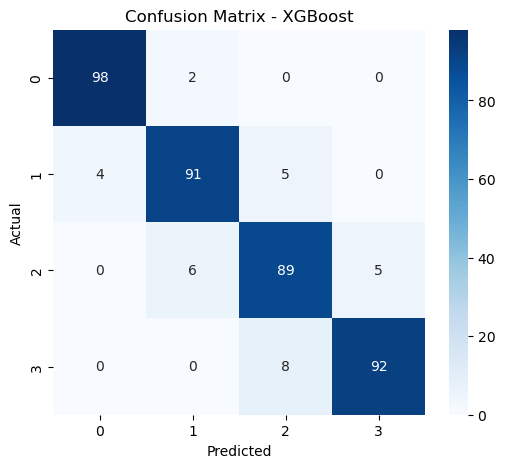

In [41]:
# Model Evaluation
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [42]:
# Ordinal Logistic Regression
from mord import LogisticIT  

In [43]:
# Ordinal Logistic Regression Pipeline
ordinal_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticIT())
])

ordinal_model.fit(X_train, y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,verbose,0
,max_iter,1000


In [44]:
# Evaluation
y_pred_ord = ordinal_model.predict(X_test)

print("Ordinal Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_ord))
print(classification_report(y_test, y_pred_ord))

cm = confusion_matrix(y_test, y_pred_ord)
print("Confusion Matrix:\n", cm)


Ordinal Logistic Regression Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.97      0.98      0.98       100
           2       0.98      0.97      0.97       100
           3       0.98      0.99      0.99       100

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix:
 [[98  2  0  0]
 [ 1 98  1  0]
 [ 0  1 97  2]
 [ 0  0  1 99]]


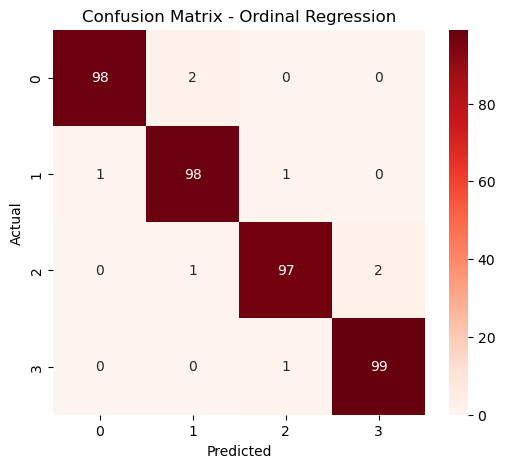

In [48]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ordinal Regression")
plt.show()

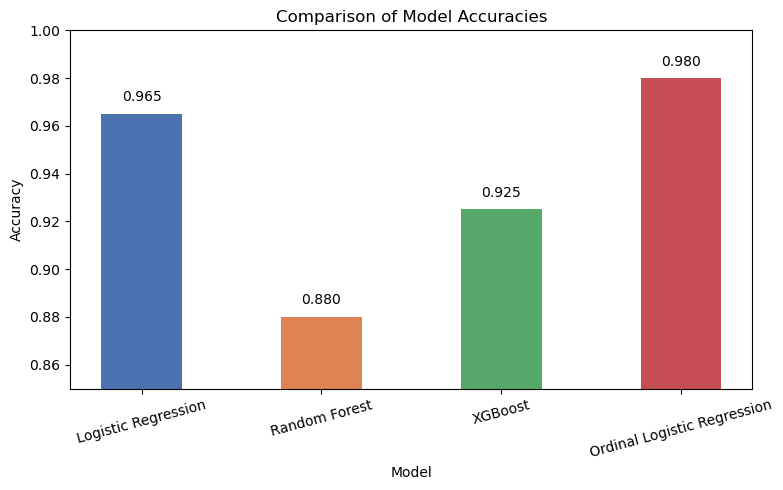

In [46]:
import matplotlib.pyplot as plt

# Model names and accuracies
models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "Ordinal Logistic Regression"
]

accuracies = [0.965, 0.88, 0.925, 0.98]

# Distinct, professional colors
colors = [
    "#4C72B0",  # Blue
    "#DD8452",  # Orange
    "#55A868",  # Green
    "#C44E52"   # Red
]

# Create bar chart with lean bars
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.45)

# Labels and title
plt.ylabel("Accuracy")
plt.xlabel("")
plt.title("Comparison of Model Accuracies")

# Focused y-axis range
plt.ylim(0.85, 1.0)

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.004,
        f"{acc:.3f}",
        ha="center",
        va="bottom"
    )

# Improve readability
plt.xticks(rotation=15)
plt.tight_layout()

# Display plot
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()
